# Data audit: DESED and FSD50K

This notebook looks at the files we already downloaded. It counts clips, events, class labels, and overlaps. It also draws a few waveforms and log-mel pictures so we can see the timestamps.

A log-mel picture is a view of the sound: time on the x axis, frequency band on the y axis, loudness as the color. It is not a decision to use a convolutional network.

No model is trained here. The raw archives are only read.

Kernel: `nndl-project`. That kernel runs `.venv\Scripts\python.exe` in this project. In JupyterLab, select that kernel if the notebook does not already use it.

## How to read the paths

Start JupyterLab from the project root (`uv run jupyter lab`). The code below walks up from the working directory until it finds `pyproject.toml` and `data/raw`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import display

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 120)


def find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "pyproject.toml").exists() and (cand / "data" / "raw").exists():
            return cand
    raise FileNotFoundError(
        "Could not find the project. Start JupyterLab from neural_networks_and_deep_learning_project."
    )


ROOT = find_root()
DESED = ROOT / "data" / "raw" / "desed"
FSD = ROOT / "data" / "raw" / "fsd50k"
FIG = ROOT / "reports" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

DESED_CLASSES = [
    "Alarm_bell_ringing",
    "Blender",
    "Cat",
    "Dishes",
    "Dog",
    "Electric_shaver_toothbrush",
    "Frying",
    "Running_water",
    "Speech",
    "Vacuum_cleaner",
]
CLASS_COLORS = {name: plt.cm.tab10(i) for i, name in enumerate(DESED_CLASSES)}

# FSD50K label strings that sit near our street list. This is a look at the
# vocabulary, not a frozen map. A clip is counted once per group if any of
# these names appears in its label list.
STREET_GROUPS = {
    "speech_crowd": [
        "Speech",
        "Male_speech_and_man_speaking",
        "Female_speech_and_woman_speaking",
        "Child_speech_and_kid_speaking",
        "Conversation",
        "Chatter",
        "Crowd",
        "Cheering",
        "Shout",
        "Yell",
    ],
    "car_horn": ["Vehicle_horn_and_car_horn_and_honking"],
    "siren": ["Siren"],
    "engine_traffic": [
        "Engine",
        "Engine_starting",
        "Accelerating_and_revving_and_vroom",
        "Idling",
        "Car_passing_by",
        "Motor_vehicle_(road)",
        "Traffic_noise_and_roadway_noise",
        "Bus",
        "Truck",
        "Race_car_and_auto_racing",
    ],
    "two_wheeler": ["Motorcycle"],
    "construction": ["Drill", "Hammer", "Power_tool", "Sawing", "Tools"],
    "dog": ["Dog", "Bark"],
    "music": ["Music", "Musical_instrument"],
    "bird": ["Bird", "Bird_vocalization_and_bird_call_and_bird_song"],
}


def read_tsv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t")


def wav_files(folder: Path) -> list[Path]:
    return sorted(p for p in folder.glob("*.wav") if not p.name.startswith("._"))


def to_wav_name(name: str) -> str:
    text = str(name)
    if text.endswith(".wav"):
        return text
    if text.endswith(".jams"):
        return text[: -len(".jams")] + ".wav"
    return Path(text).stem + ".wav"


def class_counts(frame: pd.DataFrame, clip_col: str, label_col: str) -> tuple[pd.Series, pd.Series]:
    events = frame[label_col].value_counts().reindex(DESED_CLASSES, fill_value=0)
    clip_sets = frame.groupby(clip_col)[label_col].agg(lambda s: set(s))
    exploded = clip_sets.explode()
    clips = exploded.value_counts().reindex(DESED_CLASSES, fill_value=0)
    return events, clips


def overlap_report(frame: pd.DataFrame, clip_col: str, label_col: str) -> dict:
    per_clip = frame.groupby(clip_col)[label_col].agg(lambda s: set(s))
    n_classes = per_clip.map(len)
    co_present = int((n_classes >= 2).sum())
    temporal = 0
    if {"onset", "offset"}.issubset(frame.columns):
        for _, group in frame.groupby(clip_col):
            rows = list(group[[label_col, "onset", "offset"]].itertuples(index=False))
            hit = False
            for i in range(len(rows)):
                for j in range(i + 1, len(rows)):
                    if rows[i][0] == rows[j][0]:
                        continue
                    if rows[i][1] < rows[j][2] and rows[j][1] < rows[i][2]:
                        hit = True
                        break
                if hit:
                    break
            temporal += int(hit)
    return {
        "clips": int(n_classes.shape[0]),
        "clips_with_2plus_classes": co_present,
        "share_with_2plus_classes": co_present / max(int(n_classes.shape[0]), 1),
        "clips_with_time_overlap": temporal,
        "share_with_time_overlap": temporal / max(int(n_classes.shape[0]), 1),
        "classes_per_clip": n_classes,
    }


def cooccurrence(frame: pd.DataFrame, clip_col: str, label_col: str) -> pd.DataFrame:
    labels = DESED_CLASSES
    index = {name: i for i, name in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for labs in frame.groupby(clip_col)[label_col].agg(lambda s: set(s)):
        present = [lab for lab in labs if lab in index]
        for a in present:
            for b in present:
                matrix[index[a], index[b]] += 1
    return pd.DataFrame(matrix, index=labels, columns=labels)


def save_fig(fig: plt.Figure, name: str) -> Path:
    path = FIG / name
    fig.savefig(path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path


def barh_counts(series: pd.Series, title: str, xlabel: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ordered = series.reindex(DESED_CLASSES)
    ax.barh(ordered.index[::-1], ordered.values[::-1], color="#3d5a80")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    fig.tight_layout()
    save_fig(fig, filename)


def duration_hist(frame: pd.DataFrame, title: str, filename: str) -> None:
    duration = frame["offset"] - frame["onset"]
    bad = int((duration <= 0).sum())
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(duration.clip(lower=0, upper=10), bins=20, range=(0, 10), color="#3d5a80")
    ax.set_title(title + f"  (durations <= 0: {bad})")
    ax.set_xlabel("Event length in seconds")
    ax.set_ylabel("Events")
    fig.tight_layout()
    save_fig(fig, filename)


def overlap_hist(n_classes: pd.Series, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    counts = n_classes.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#3d5a80")
    ax.set_title(title)
    ax.set_xlabel("Distinct classes in the clip")
    ax.set_ylabel("Clips")
    fig.tight_layout()
    save_fig(fig, filename)


def cooccurrence_heatmap(matrix: pd.DataFrame, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6.5))
    image = ax.imshow(matrix.values, cmap="Blues")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046)
    fig.tight_layout()
    save_fig(fig, filename)


print("Project root:", ROOT)
print("Figures:", FIG)

Project root: C:\Users\gaura\Documents\grok_build_trial\neural_networks_and_deep_learning_project
Figures: C:\Users\gaura\Documents\grok_build_trial\neural_networks_and_deep_learning_project\reports\eda


## 1. What is on disk

Each row says whether the wave files are in this folder or only the labels are.

In [2]:
public_wav_dir = DESED / "audio" / "eval" / "public"
public_tsv = DESED / "metadata" / "eval" / "public.tsv"
weak_tsv = DESED / "metadata" / "train" / "weak.tsv"
unlabel_tsv = DESED / "metadata" / "train" / "unlabel_in_domain.tsv"
validation_tsv = DESED / "metadata" / "validation" / "validation.tsv"
audioset_strong_tsv = DESED / "audioset_strong.tsv"
synth_root = DESED / "dcase2019" / "dataset"
synth_audio = synth_root / "audio" / "eval" / "fbsnr_30dB"
synth_tsv = synth_root / "metadata" / "eval" / "fbsnr_30dB.tsv"
fsd_dev = FSD / "FSD50K.ground_truth" / "dev.csv"
fsd_eval = FSD / "FSD50K.ground_truth" / "eval.csv"
fsd_vocab = FSD / "FSD50K.ground_truth" / "vocabulary.csv"

public_wavs = wav_files(public_wav_dir)
synth_wavs = wav_files(synth_audio)
other_synth_dirs = sorted(
    p for p in (synth_root / "audio" / "eval").iterdir()
    if p.is_dir() and not p.name.startswith("._") and p.name != "fbsnr_30dB"
)

inventory = pd.DataFrame(
    [
        {
            "set": "DESED public eval",
            "path": str(public_wav_dir.relative_to(ROOT)),
            "audio_files": len(public_wavs),
            "labels": "strong: onset and offset",
            "audio_local": True,
        },
        {
            "set": "DESED validation",
            "path": str(validation_tsv.relative_to(ROOT)),
            "audio_files": 0,
            "labels": "strong: onset and offset",
            "audio_local": False,
        },
        {
            "set": "DESED weak train",
            "path": str(weak_tsv.relative_to(ROOT)),
            "audio_files": 0,
            "labels": "weak: clip tags only",
            "audio_local": False,
        },
        {
            "set": "DESED unlabeled train",
            "path": str(unlabel_tsv.relative_to(ROOT)),
            "audio_files": 0,
            "labels": "file names only",
            "audio_local": False,
        },
        {
            "set": "AudioSet strong subset",
            "path": str(audioset_strong_tsv.relative_to(ROOT)),
            "audio_files": 0,
            "labels": "strong: onset and offset",
            "audio_local": False,
        },
        {
            "set": "DESED synthetic eval, fbsnr_30dB",
            "path": str(synth_audio.relative_to(ROOT)),
            "audio_files": len(synth_wavs),
            "labels": "strong, filename stem matches the wav",
            "audio_local": True,
        },
        {
            "set": "DESED synthetic eval, other conditions",
            "path": str((synth_root / "audio" / "eval").relative_to(ROOT)),
            "audio_files": sum(len(wav_files(p)) for p in other_synth_dirs),
            "labels": "same scenes under other duration, noise, or distortion settings",
            "audio_local": True,
        },
        {
            "set": "FSD50K dev and eval labels",
            "path": str((FSD / "FSD50K.ground_truth").relative_to(ROOT)),
            "audio_files": 0,
            "labels": "weak: clip tags, no onset or offset",
            "audio_local": False,
        },
    ]
)
display(inventory)
inventory.to_csv(FIG / "inventory.csv", index=False)

,set,path,audio_files,labels,audio_local
0,DESED public eval,data\raw\desed\audio\eval\public,692,strong: onset and offset,True
1,DESED validation,data\raw\desed\metadata\validation\validation.tsv,0,strong: onset and offset,False
2,DESED weak train,data\raw\desed\metadata\train\weak.tsv,0,weak: clip tags only,False
3,DESED unlabeled train,data\raw\desed\metadata\train\unlabel_in_domain.tsv,0,file names only,False
4,AudioSet strong subset,data\raw\desed\audioset_strong.tsv,0,strong: onset and offset,False
5,"DESED synthetic eval, fbsnr_30dB",data\raw\desed\dcase2019\dataset\audio\eval\fbsnr_30dB,754,"strong, filename stem matches the wav",True
6,"DESED synthetic eval, other conditions",data\raw\desed\dcase2019\dataset\audio\eval,11385,"same scenes under other duration, noise, or distortion settings",True
7,FSD50K dev and eval labels,data\raw\fsd50k\FSD50K.ground_truth,0,"weak: clip tags, no onset or offset",False


## 2. DESED public eval

These are real 10 second clips with start and end times. The wave folder and `public.tsv` should name the same 692 files.

events 2765
clips in tsv 692
wav files 692
tsv names missing a wav 0
wav names missing a tsv row 0
event length min / median / max seconds: 0.25 0.849 10.142


,events,clips
event_label,,
Alarm_bell_ringing,196,79
Blender,84,73
Cat,240,70
Dishes,488,136
Dog,441,82
Electric_shaver_toothbrush,108,84
Frying,90,88
Running_water,109,92
Speech,913,314


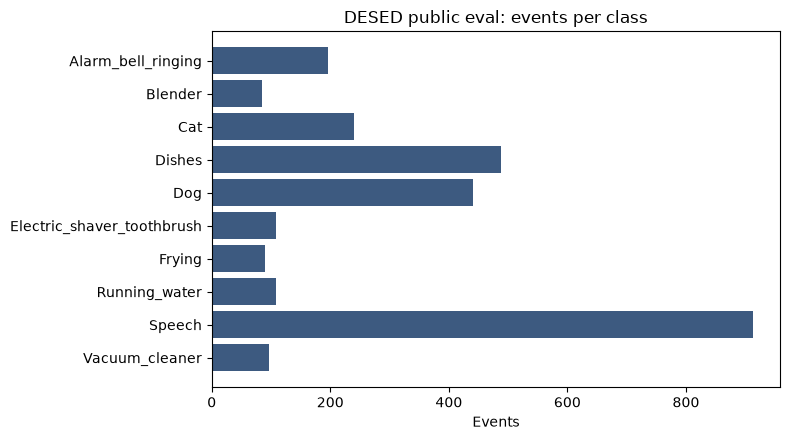

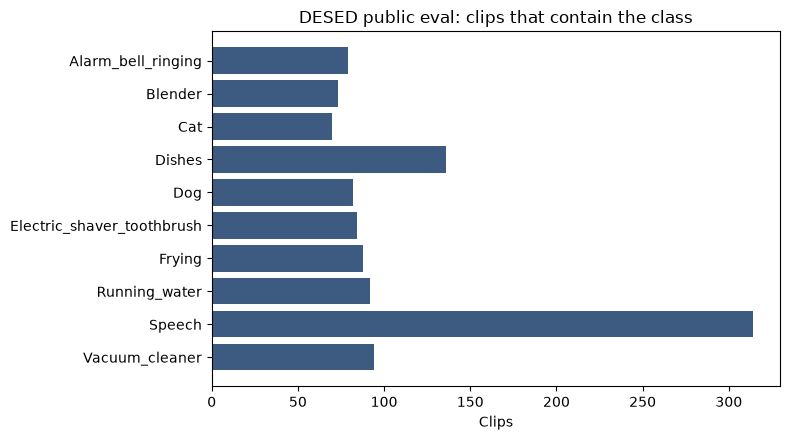

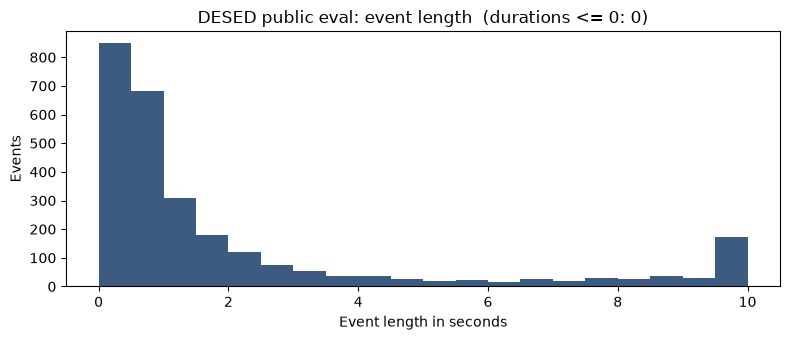

clips 692 | with 2 or more classes 355 (51.3%) | with two classes overlapping in time 259 (37.4%)


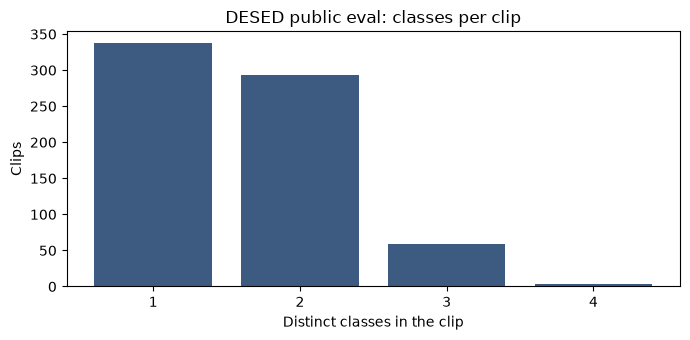

,Alarm_bell_ringing,Blender,Cat,Dishes,Dog,Electric_shaver_toothbrush,Frying,Running_water,Speech,Vacuum_cleaner
Alarm_bell_ringing,79,0,1,0,6,2,0,0,25,0
Blender,0,73,0,12,0,0,0,3,54,0
Cat,1,0,70,3,2,0,0,2,26,0
Dishes,0,12,3,136,2,0,52,18,90,1
Dog,6,0,2,2,82,0,1,4,25,0
Electric_shaver_toothbrush,2,0,0,0,0,84,0,1,56,0
Frying,0,0,0,52,1,0,88,1,52,0
Running_water,0,3,2,18,4,1,1,92,23,0
Speech,25,54,26,90,25,56,52,23,314,26
Vacuum_cleaner,0,0,0,1,0,0,0,0,26,94


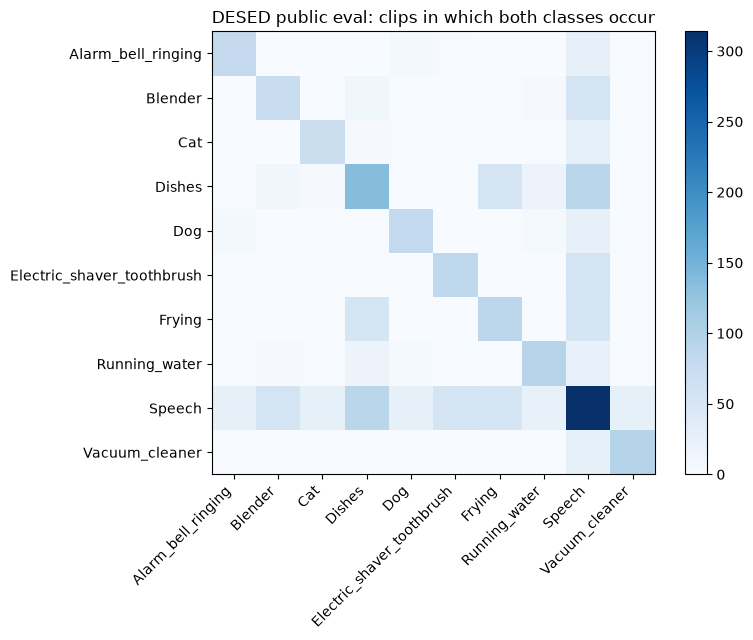

In [3]:
public = read_tsv(public_tsv)
public["duration"] = public["offset"] - public["onset"]
public_names = set(public["filename"])
wav_names = {p.name for p in public_wavs}
print("events", len(public))
print("clips in tsv", public["filename"].nunique())
print("wav files", len(wav_names))
print("tsv names missing a wav", len(public_names - wav_names))
print("wav names missing a tsv row", len(wav_names - public_names))
print("event length min / median / max seconds:",
      round(public["duration"].min(), 3),
      round(public["duration"].median(), 3),
      round(public["duration"].max(), 3))

public_events, public_clips = class_counts(public, "filename", "event_label")
summary = pd.DataFrame({"events": public_events, "clips": public_clips})
display(summary)
summary.to_csv(FIG / "public_eval_class_counts.csv")

barh_counts(public_events, "DESED public eval: events per class", "Events", "public_eval_events.png")
barh_counts(public_clips, "DESED public eval: clips that contain the class", "Clips", "public_eval_clips.png")
duration_hist(public, "DESED public eval: event length", "public_eval_duration.png")

public_overlap = overlap_report(public, "filename", "event_label")
print(
    "clips", public_overlap["clips"],
    "| with 2 or more classes", public_overlap["clips_with_2plus_classes"],
    f"({public_overlap['share_with_2plus_classes']:.1%})",
    "| with two classes overlapping in time", public_overlap["clips_with_time_overlap"],
    f"({public_overlap['share_with_time_overlap']:.1%})",
)
overlap_hist(public_overlap["classes_per_clip"], "DESED public eval: classes per clip", "public_eval_overlap.png")
public_co = cooccurrence(public, "filename", "event_label")
display(public_co)
public_co.to_csv(FIG / "public_eval_cooccurrence.csv")
cooccurrence_heatmap(
    public_co,
    "DESED public eval: clips in which both classes occur",
    "public_eval_cooccurrence.png",
)

## 3. Validation and weak train

These tables have labels. The wave files are not in this folder. The validation file has start and end times. The weak file only says which classes are somewhere in the clip. The unlabeled file is a list of names.

validation events 4239 clips 1168
validation wavs on disk: 0


,events,clips
event_label,,
Alarm_bell_ringing,420,187
Blender,94,80
Cat,341,121
Dishes,559,171
Dog,570,160
Electric_shaver_toothbrush,65,62
Frying,94,89
Running_water,237,197
Speech,1752,627


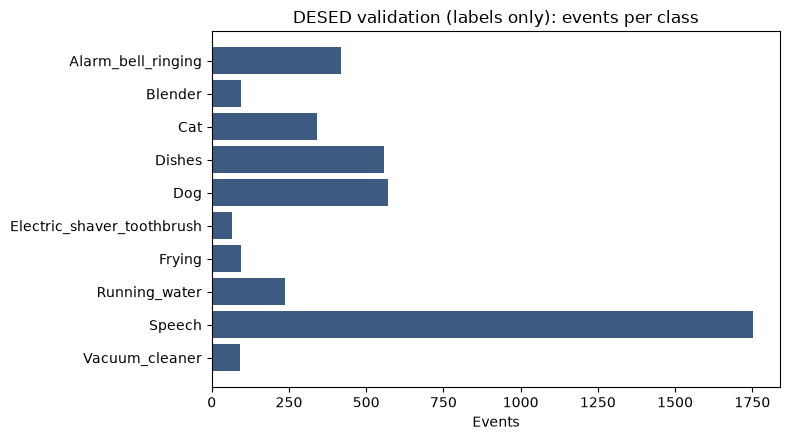

validation clips with 2 or more classes 556 (47.6%) | time overlap 391 (33.5%)
weak clips 1578 tag rows after split 2247
weak wavs on disk: 0


,clips
event_label,
Alarm_bell_ringing,205
Blender,134
Cat,173
Dishes,184
Dog,214
Electric_shaver_toothbrush,103
Frying,171
Running_water,343
Speech,550


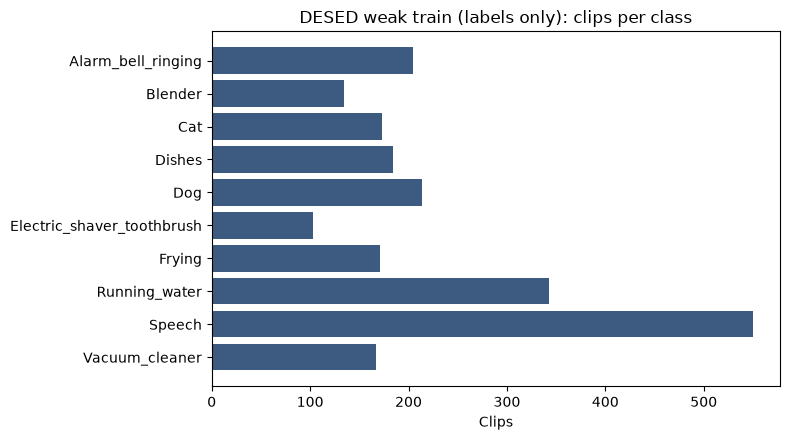

weak clips with 2 or more classes 592 (37.5%)
unlabeled file names 14412 wavs on disk: 0
AudioSet strong subset events 15446 clips 3470 wavs on disk: 0


,events
event_label,
Alarm_bell_ringing,1723
Blender,219
Cat,440
Dishes,2017
Dog,1379
Electric_shaver_toothbrush,214
Frying,526
Running_water,596
Speech,8246


In [4]:
validation = read_tsv(validation_tsv)
validation["duration"] = validation["offset"] - validation["onset"]
print("validation events", len(validation), "clips", validation["filename"].nunique())
print("validation wavs on disk: 0")
val_events, val_clips = class_counts(validation, "filename", "event_label")
val_summary = pd.DataFrame({"events": val_events, "clips": val_clips})
display(val_summary)
val_summary.to_csv(FIG / "validation_class_counts.csv")
barh_counts(val_events, "DESED validation (labels only): events per class", "Events", "validation_events.png")
val_overlap = overlap_report(validation, "filename", "event_label")
print(
    "validation clips with 2 or more classes",
    val_overlap["clips_with_2plus_classes"],
    f"({val_overlap['share_with_2plus_classes']:.1%})",
    "| time overlap",
    val_overlap["clips_with_time_overlap"],
    f"({val_overlap['share_with_time_overlap']:.1%})",
)

weak = read_tsv(weak_tsv)
weak_long = weak.assign(event_label=weak["event_labels"].str.split(",")).explode("event_label")
weak_long["event_label"] = weak_long["event_label"].str.strip()
print("weak clips", weak["filename"].nunique(), "tag rows after split", len(weak_long))
print("weak wavs on disk: 0")
_, weak_clips = class_counts(weak_long, "filename", "event_label")
display(weak_clips.to_frame("clips"))
weak_clips.to_csv(FIG / "weak_class_counts.csv", header=["clips"])
barh_counts(weak_clips, "DESED weak train (labels only): clips per class", "Clips", "weak_clips.png")
weak_sets = weak_long.groupby("filename")["event_label"].agg(lambda s: set(s)).map(len)
print("weak clips with 2 or more classes", int((weak_sets >= 2).sum()), f"({(weak_sets >= 2).mean():.1%})")

unlabel = read_tsv(unlabel_tsv)
print("unlabeled file names", len(unlabel), "wavs on disk: 0")

strong = read_tsv(audioset_strong_tsv)
print(
    "AudioSet strong subset events", len(strong),
    "clips", strong["filename"].nunique(),
    "wavs on disk: 0",
)
strong_events, _ = class_counts(strong, "filename", "event_label")
display(strong_events.to_frame("events"))

## 4. Synthetic eval, one condition

`fbsnr_30dB` is one setting of the DCASE 2019 synthetic evaluation scenes. The label file stores `1.jams` where the audio file is `1.wav`. The other condition folders are the same kind of scene with a different length, noise level, or distortion. Adding them together would count the same idea many times, so the totals below use only `fbsnr_30dB`.

events 2133
clips in tsv 754
wav files 754
tsv names missing a wav 0
wav names missing a tsv row 0


,events,clips
event_label,,
Alarm_bell_ringing,184,101
Blender,88,78
Cat,197,113
Dishes,294,162
Dog,217,124
Electric_shaver_toothbrush,117,113
Frying,20,20
Running_water,73,67
Speech,803,471


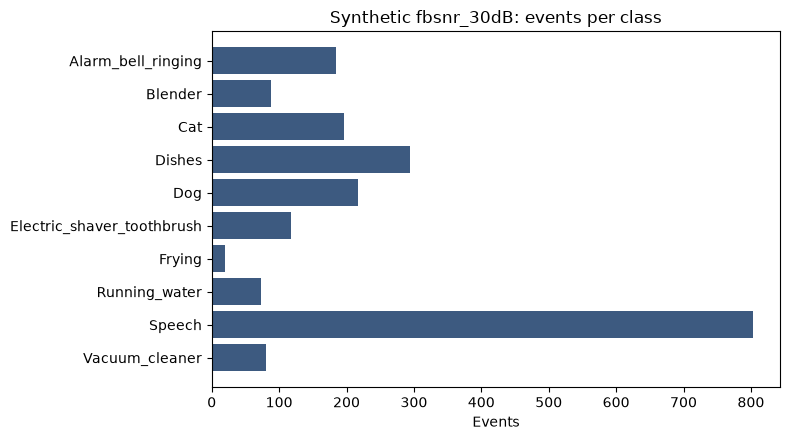

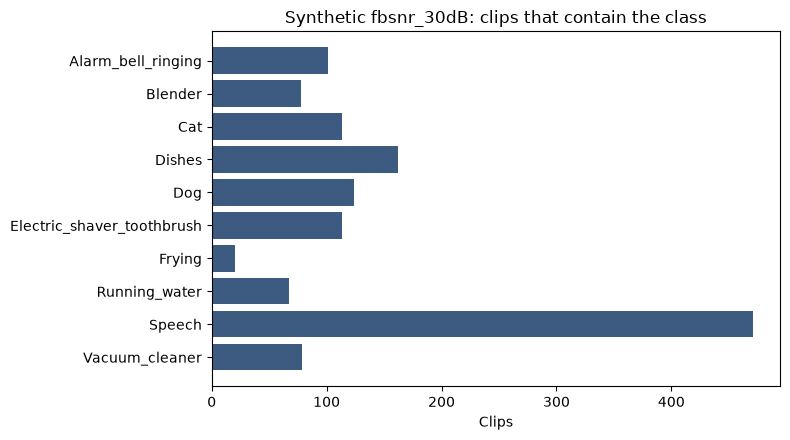

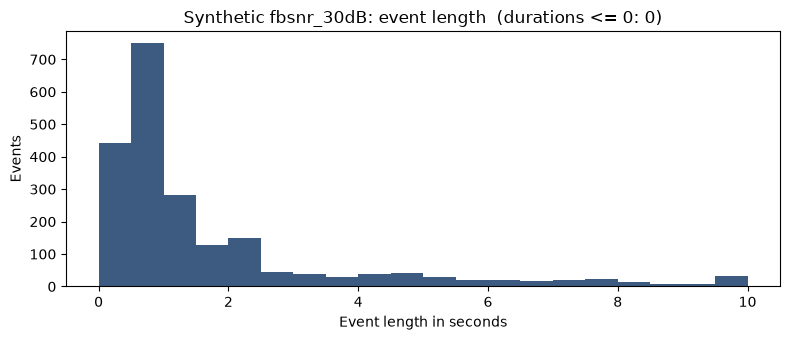

clips 754 | with 2 or more classes 495 (65.6%) | with two classes overlapping in time 321 (42.6%)


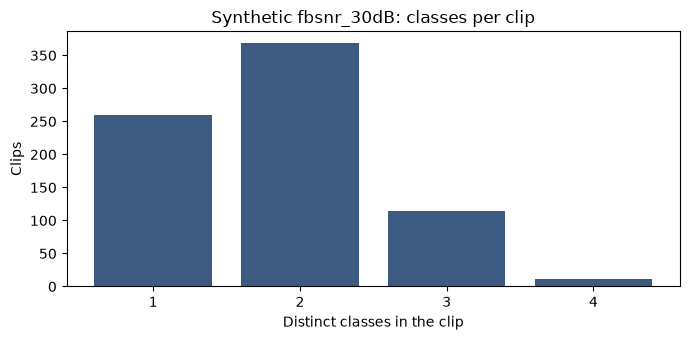

Other synthetic condition folders, not added into the totals above:
  500ms: 750 wavs
  5500ms: 750 wavs
  9500ms: 750 wavs
  distorted_clipping: 754 wavs
  distorted_drc: 754 wavs
  distorted_highpass_filter: 754 wavs
  distorted_lowpass_filter: 754 wavs


  distorted_smartphone_playback: 754 wavs
  distorted_smartphone_recording: 754 wavs
  fbsnr_0dB: 754 wavs
  fbsnr_15dB: 754 wavs
  fbsnr_24dB: 754 wavs
  ls_0dB: 783 wavs
  ls_15dB: 783 wavs
  ls_30dB: 783 wavs


In [5]:
synth = read_tsv(synth_tsv)
synth["wav_name"] = synth["filename"].map(to_wav_name)
synth["duration"] = synth["offset"] - synth["onset"]
synth_names = set(synth["wav_name"])
synth_disk = {p.name for p in synth_wavs}
print("events", len(synth))
print("clips in tsv", synth["wav_name"].nunique())
print("wav files", len(synth_disk))
print("tsv names missing a wav", len(synth_names - synth_disk))
print("wav names missing a tsv row", len(synth_disk - synth_names))

synth_events, synth_clips = class_counts(synth, "wav_name", "event_label")
synth_summary = pd.DataFrame({"events": synth_events, "clips": synth_clips})
display(synth_summary)
synth_summary.to_csv(FIG / "synth_fbsnr30_class_counts.csv")
barh_counts(synth_events, "Synthetic fbsnr_30dB: events per class", "Events", "synth_fbsnr30_events.png")
barh_counts(synth_clips, "Synthetic fbsnr_30dB: clips that contain the class", "Clips", "synth_fbsnr30_clips.png")
duration_hist(synth, "Synthetic fbsnr_30dB: event length", "synth_fbsnr30_duration.png")
synth_overlap = overlap_report(synth, "wav_name", "event_label")
print(
    "clips", synth_overlap["clips"],
    "| with 2 or more classes", synth_overlap["clips_with_2plus_classes"],
    f"({synth_overlap['share_with_2plus_classes']:.1%})",
    "| with two classes overlapping in time", synth_overlap["clips_with_time_overlap"],
    f"({synth_overlap['share_with_time_overlap']:.1%})",
)
overlap_hist(synth_overlap["classes_per_clip"], "Synthetic fbsnr_30dB: classes per clip", "synth_fbsnr30_overlap.png")

print("Other synthetic condition folders, not added into the totals above:")
for folder in other_synth_dirs:
    print(f"  {folder.name}: {len(wav_files(folder))} wavs")

## 5. FSD50K labels

FSD50K has clip tags and no start or end time. The dev file has an official `split` column (`train` or `val`). This notebook leaves that column as it was published. `vocabulary.csv` has no header.

FSD50K copies parent names onto a clip. A guitar clip is also tagged `Music` and `Musical_instrument`. The music count is large for that reason. A clip is counted once in a group below if any listed name is present. One clip can sit in more than one group.

vocabulary rows 200 (expect 200)
dev clips 40966 eval clips 10231
dev split counts:


split
train    36796
val       4170
Name: count, dtype: int64

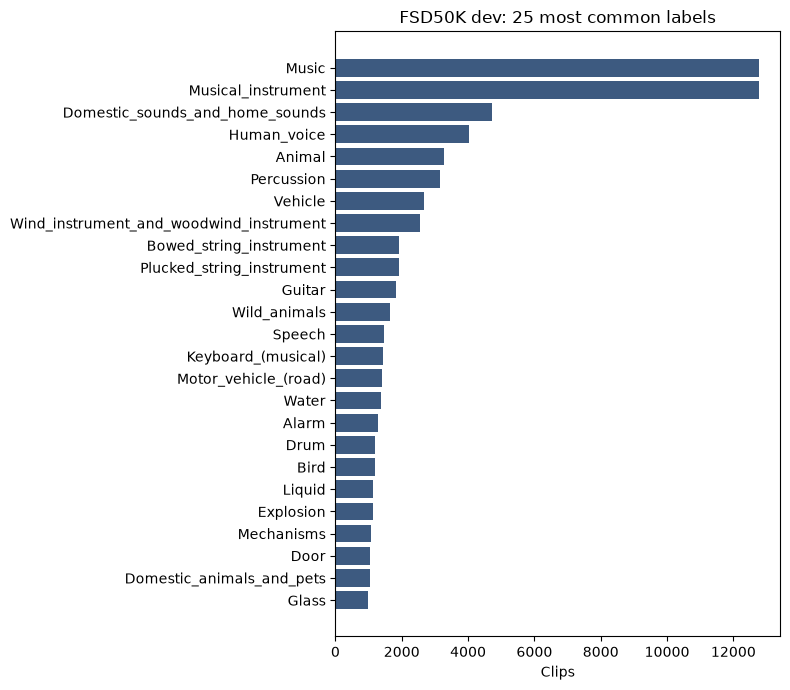

,dev,eval,names
speech_crowd,2105,1258,"Speech, Male_speech_and_man_speaking, Female_speech_and_woman_speaking, Child_speech_and_kid_speaking, Conversation,..."
car_horn,115,68,Vehicle_horn_and_car_horn_and_honking
siren,77,55,Siren
engine_traffic,1930,811,"Engine, Engine_starting, Accelerating_and_revving_and_vroom, Idling, Car_passing_by, Motor_vehicle_(road), Traffic_n..."
two_wheeler,170,80,Motorcycle
construction,788,216,"Drill, Hammer, Power_tool, Sawing, Tools"
dog,752,178,"Dog, Bark"
music,12767,1972,"Music, Musical_instrument"
bird,1189,540,"Bird, Bird_vocalization_and_bird_call_and_bird_song"


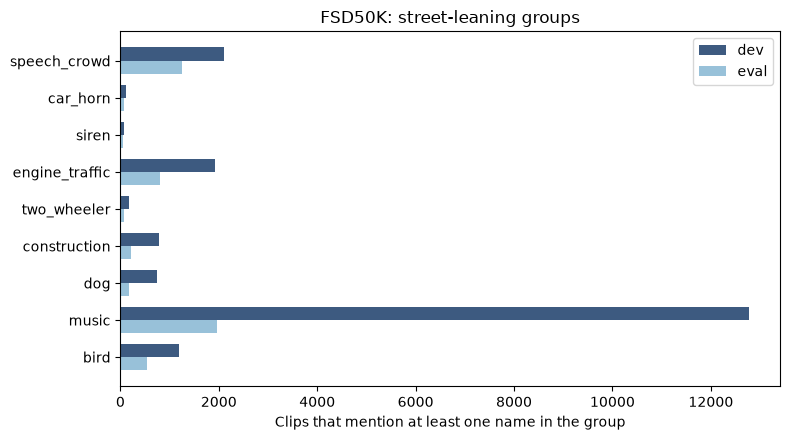

WindowsPath('C:/Users/gaura/Documents/grok_build_trial/neural_networks_and_deep_learning_project/reports/eda/fsd50k_street_groups.png')

In [6]:
dev = pd.read_csv(fsd_dev)
ev = pd.read_csv(fsd_eval)
vocab = pd.read_csv(fsd_vocab, header=None, names=["idx", "label", "mid"])
print("vocabulary rows", len(vocab), "(expect 200)")
print("dev clips", len(dev), "eval clips", len(ev))
print("dev split counts:")
display(dev["split"].value_counts())


def split_labels(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["label_list"] = out["labels"].fillna("").map(
        lambda text: [part.strip() for part in str(text).split(",") if part.strip()]
    )
    return out


dev = split_labels(dev)
ev = split_labels(ev)

def label_clip_counts(frame: pd.DataFrame) -> pd.Series:
    return frame["label_list"].explode().value_counts()


dev_counts = label_clip_counts(dev)
eval_counts = label_clip_counts(ev)
label_table = pd.DataFrame({"dev_clips": dev_counts, "eval_clips": eval_counts}).fillna(0).astype(int)
label_table = label_table.reindex(vocab["label"]).fillna(0).astype(int)
label_table.to_csv(FIG / "fsd50k_label_counts.csv")

top = dev_counts.head(25).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color="#3d5a80")
ax.set_title("FSD50K dev: 25 most common labels")
ax.set_xlabel("Clips")
fig.tight_layout()
save_fig(fig, "fsd50k_dev_top25.png")


def group_count(frame: pd.DataFrame) -> pd.Series:
    counts = {}
    lists = frame["label_list"]
    for group, names in STREET_GROUPS.items():
        wanted = set(names)
        counts[group] = int(lists.map(lambda labs: bool(wanted.intersection(labs))).sum())
    return pd.Series(counts, name="clips")


street = pd.DataFrame({"dev": group_count(dev), "eval": group_count(ev)})
street["names"] = street.index.map(lambda key: ", ".join(STREET_GROUPS[key]))
display(street)
street.to_csv(FIG / "fsd50k_street_group_counts.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(street))
ax.barh(y - 0.18, street["dev"], height=0.36, label="dev", color="#3d5a80")
ax.barh(y + 0.18, street["eval"], height=0.36, label="eval", color="#98c1d9")
ax.set_yticks(y)
ax.set_yticklabels(street.index)
ax.invert_yaxis()
ax.set_xlabel("Clips that mention at least one name in the group")
ax.set_title("FSD50K: street-leaning groups")
ax.legend()
fig.tight_layout()
save_fig(fig, "fsd50k_street_groups.png")

## 6. Waveforms and log-mel pictures

Eight public-eval clips and two synthetic `fbsnr_30dB` clips. The clips are chosen so the pictures cover as many classes as possible, with more than one class in the clip when that exists.

The log-mel uses the average of the channels when the file is stereo. Frequency bands are the mel scale. Color is log loudness. The colored strip between the waveform and the picture is the strong label. This is a figure for us to look at.

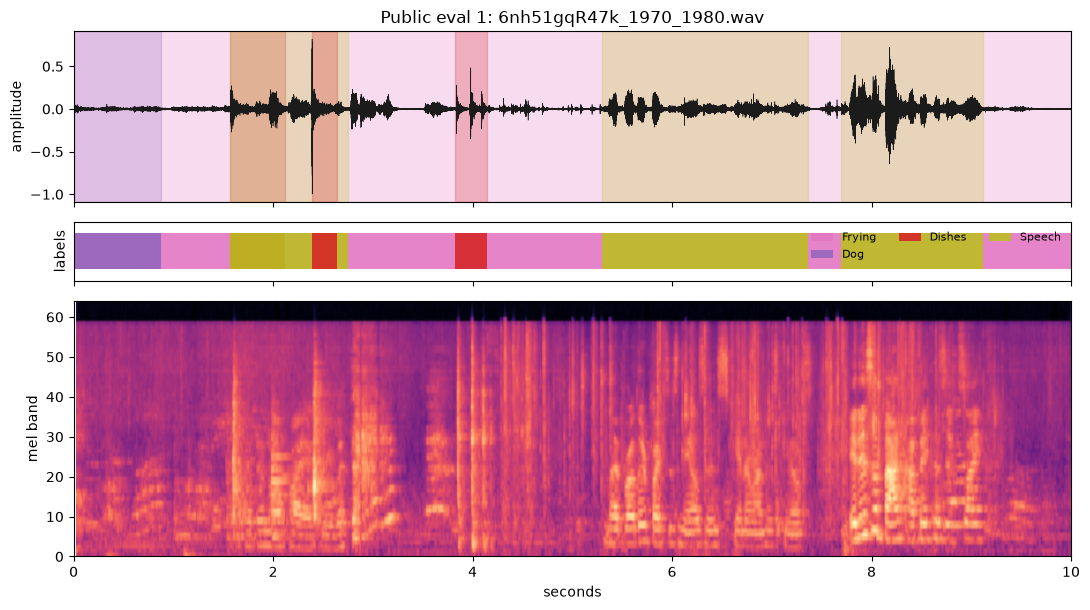

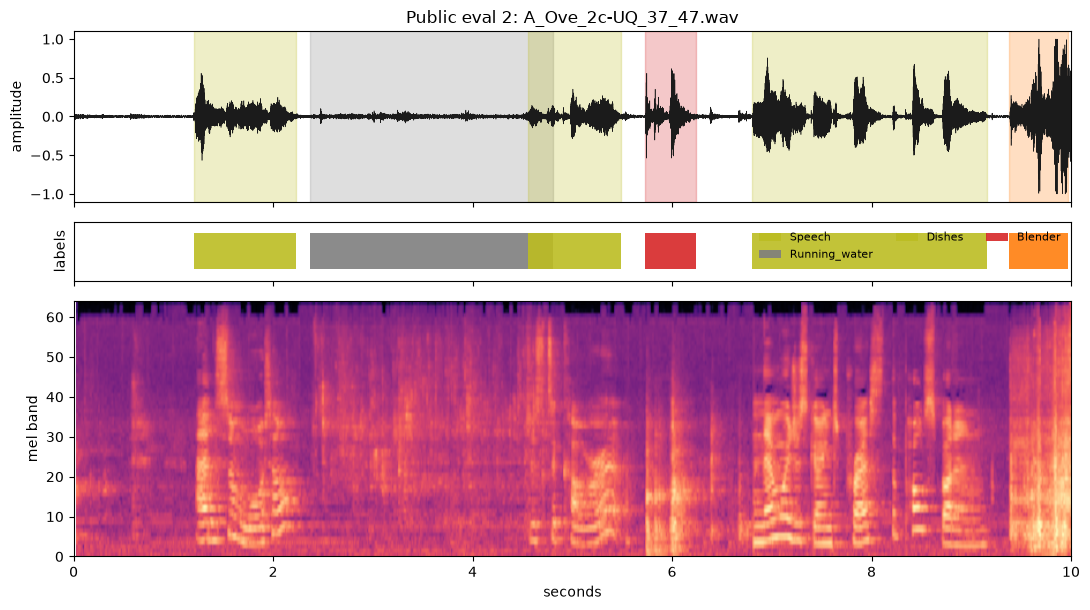

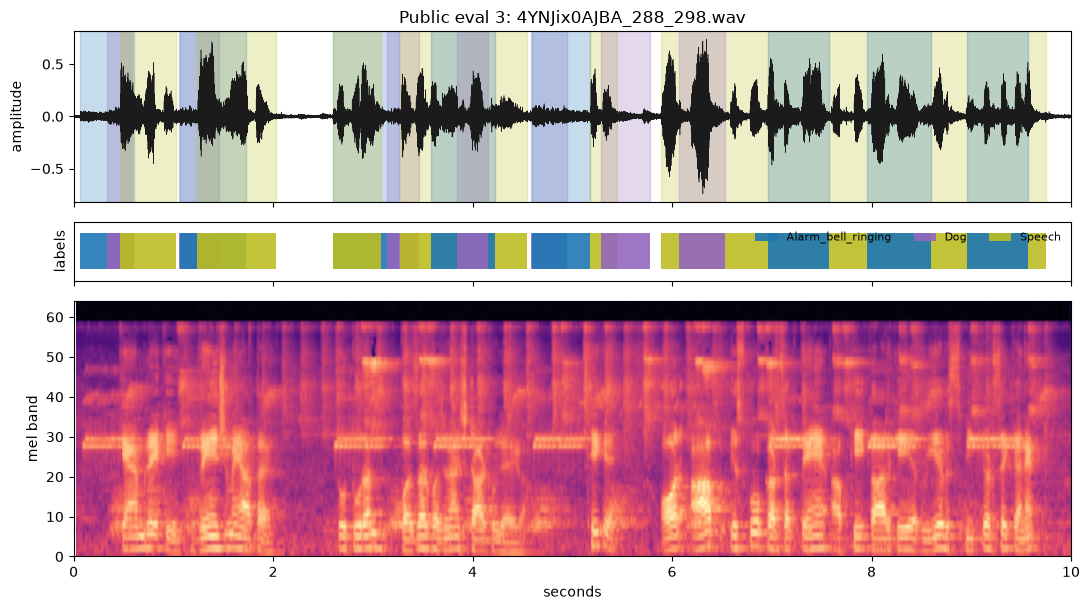

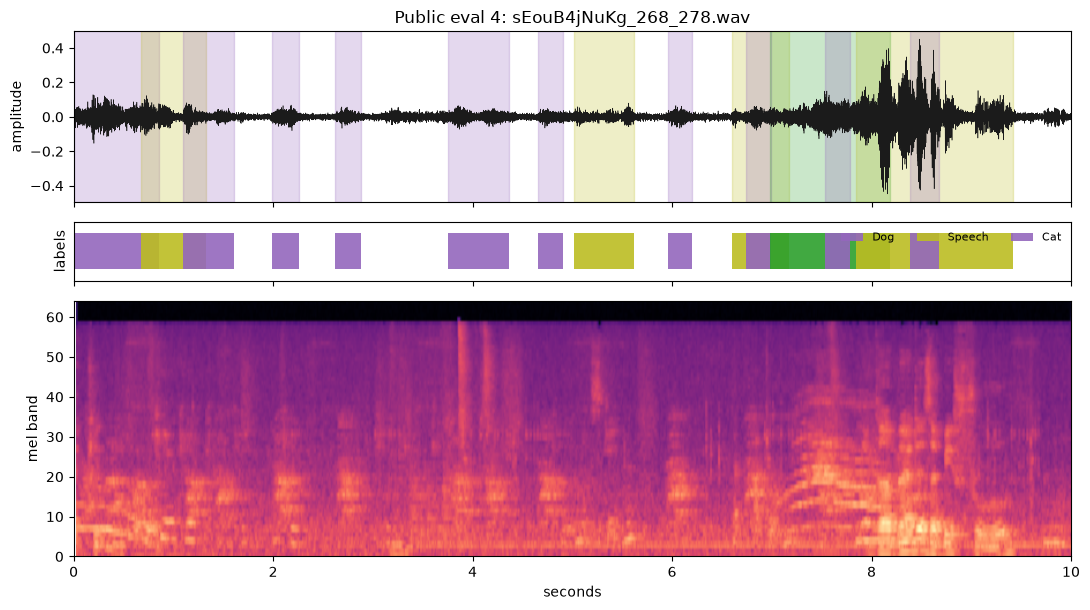

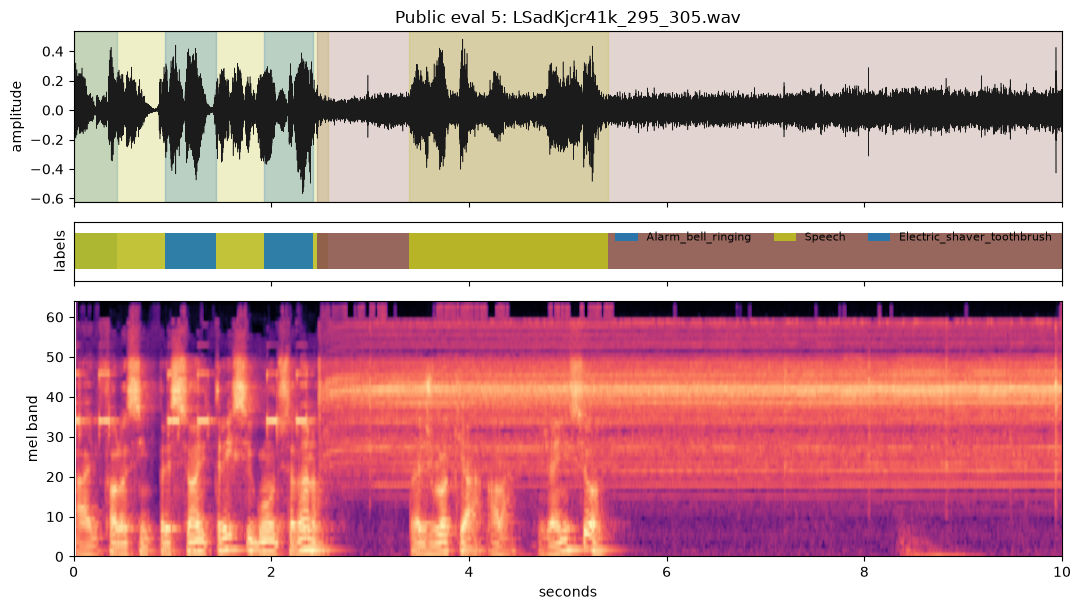

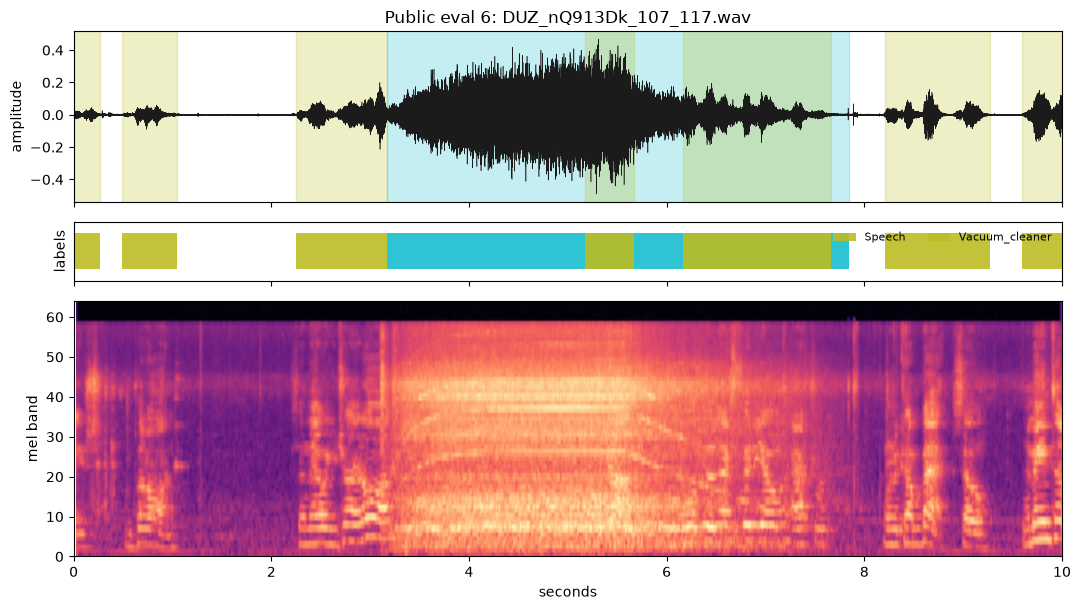

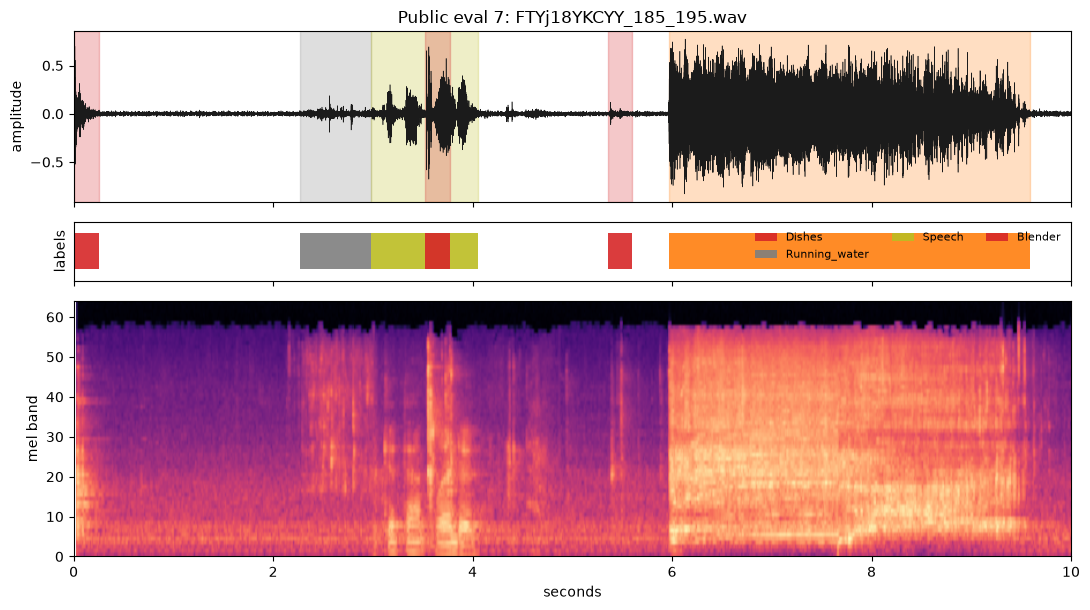

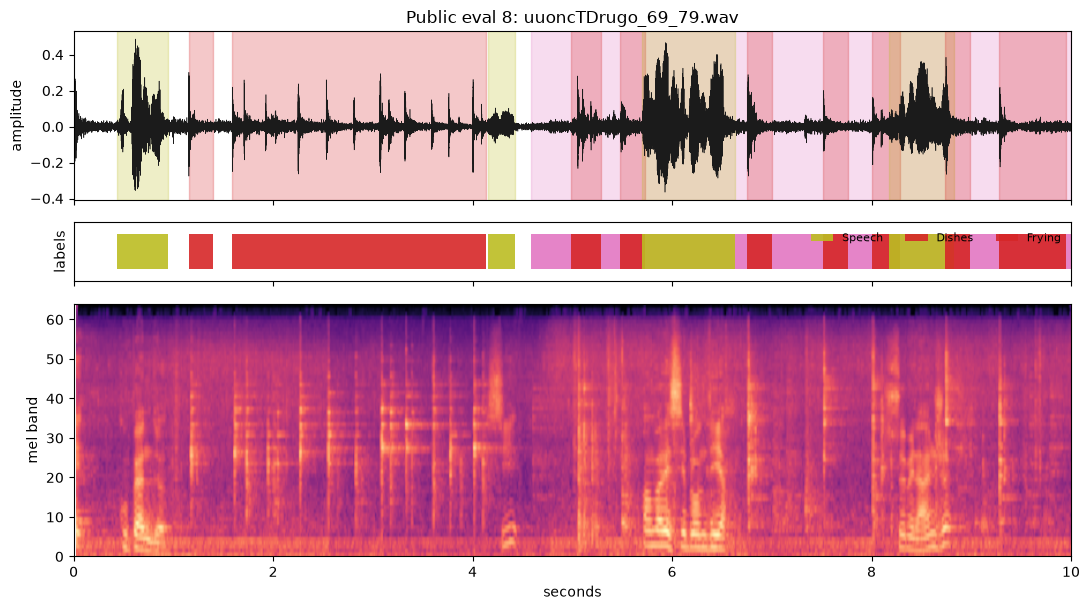

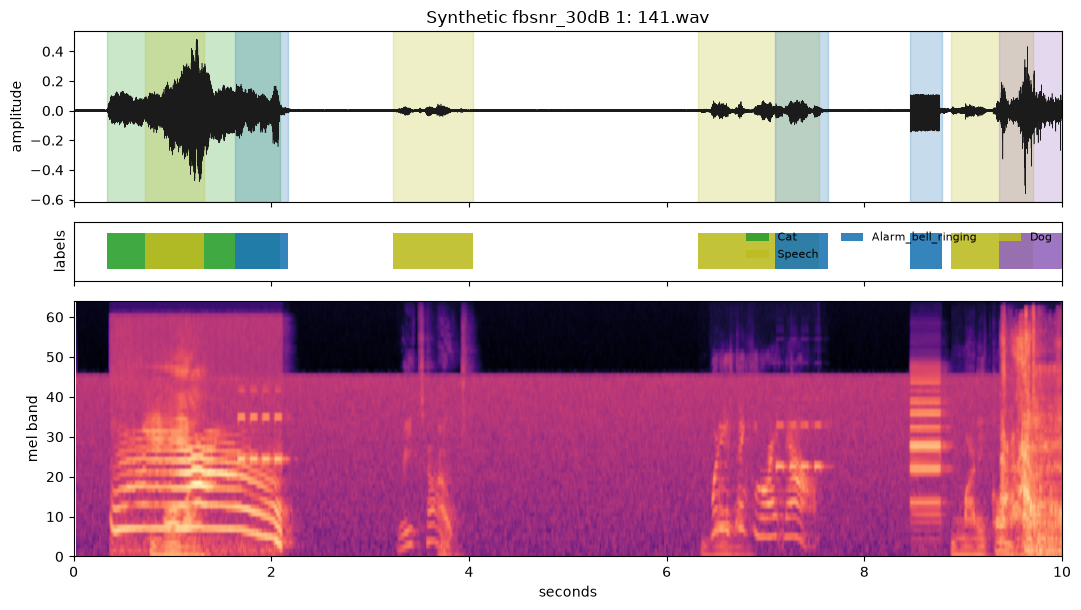

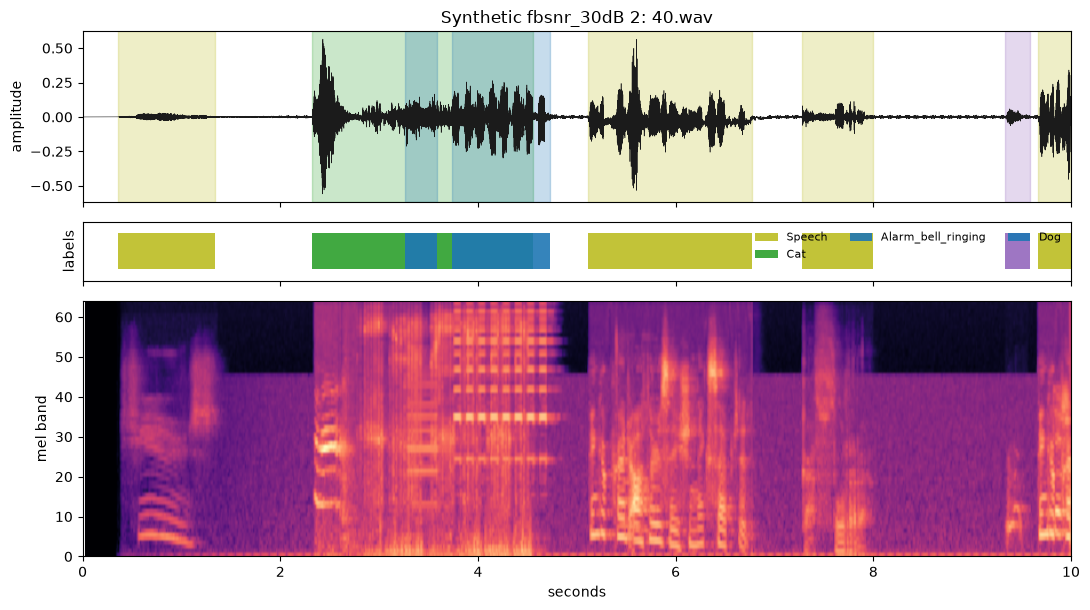

Example files


,group,file,samplerate,channels,seconds
0,example,6nh51gqR47k_1970_1980.wav,44100,2,10.0
1,example,A_Ove_2c-UQ_37_47.wav,44100,2,10.0
2,example,4YNJix0AJBA_288_298.wav,44100,2,10.0
3,example,sEouB4jNuKg_268_278.wav,44100,2,10.0
4,example,LSadKjcr41k_295_305.wav,44100,2,10.0
5,example,DUZ_nQ913Dk_107_117.wav,44100,2,10.0
6,example,FTYj18YKCYY_185_195.wav,44100,2,10.0
7,example,uuoncTDrugo_69_79.wav,44100,2,10.0
8,example,141.wav,44100,1,10.0
9,example,40.wav,44100,1,10.0


In [7]:
def hz_to_mel(hz: np.ndarray) -> np.ndarray:
    return 2595.0 * np.log10(1.0 + np.asarray(hz) / 700.0)


def mel_to_hz(mel: np.ndarray) -> np.ndarray:
    return 700.0 * (10.0 ** (np.asarray(mel) / 2595.0) - 1.0)


def mel_filterbank(sr: int, n_fft: int, n_mels: int = 64, fmin: float = 50.0) -> np.ndarray:
    fmax = sr / 2.0
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    bank = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float64)
    for i in range(n_mels):
        left, center, right = int(bins[i]), int(bins[i + 1]), int(bins[i + 2])
        if center <= left:
            center = left + 1
        if right <= center:
            right = center + 1
        for j in range(left, center):
            if 0 <= j < bank.shape[1]:
                bank[i, j] = (j - left) / (center - left)
        for j in range(center, right):
            if 0 <= j < bank.shape[1]:
                bank[i, j] = (right - j) / (right - center)
    return bank


def log_mel(y: np.ndarray, sr: int, n_fft: int = 2048, hop: int = 512, n_mels: int = 64) -> np.ndarray:
    if y.ndim == 2:
        y = y.mean(axis=1)
    y = np.asarray(y, dtype=np.float64)
    pad = n_fft // 2
    padded = np.pad(y, pad, mode="reflect") if len(y) > pad else np.pad(y, pad, mode="edge")
    if len(padded) < n_fft:
        padded = np.pad(padded, (0, n_fft - len(padded)))
    n_frames = 1 + (len(padded) - n_fft) // hop
    window = np.hanning(n_fft)
    spec = np.empty((n_fft // 2 + 1, n_frames), dtype=np.float64)
    for i in range(n_frames):
        frame = padded[i * hop : i * hop + n_fft] * window
        spec[:, i] = np.abs(np.fft.rfft(frame)) ** 2
    mel = mel_filterbank(sr, n_fft, n_mels) @ spec
    return np.log(mel + 1e-6)


def header_row(path: Path, group: str) -> dict:
    info = sf.info(str(path))
    return {
        "group": group,
        "file": path.name,
        "samplerate": info.samplerate,
        "channels": info.channels,
        "seconds": round(float(info.duration), 3),
    }


def census(paths: list[Path], group: str) -> pd.DataFrame:
    return pd.DataFrame(header_row(p, group) for p in paths)


def pick_clips(frame: pd.DataFrame, name_col: str, k: int) -> list[str]:
    rows = []
    for name, group in frame.groupby(name_col):
        classes = tuple(sorted(set(group["event_label"])))
        rows.append((str(name), classes, len(group)))
    rows.sort(key=lambda item: (-len(item[1]), -item[2], item[0]))
    picked: list[str] = []
    seen: set[str] = set()
    for name, classes, _n in rows:
        if any(label not in seen for label in classes) or len(picked) < 2:
            picked.append(name)
            seen.update(classes)
        if len(picked) >= k and len(seen) >= min(k, len(DESED_CLASSES)):
            break
    if len(picked) < k:
        for name, _classes, _n in rows:
            if name not in picked:
                picked.append(name)
            if len(picked) >= k:
                break
    return picked[:k]


def draw_clip(wav_path: Path, events: pd.DataFrame, title: str, filename: str) -> dict:
    audio, sr = sf.read(str(wav_path), always_2d=True)
    mono = audio.mean(axis=1)
    seconds = len(mono) / sr
    times = np.arange(len(mono)) / sr
    mel = log_mel(mono, sr)
    hop = 512
    mel_times = (np.arange(mel.shape[1]) * hop + 1024) / sr

    fig, axes = plt.subplots(
        3, 1, figsize=(11, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [2.0, 0.7, 3.0]},
    )
    axes[0].plot(times, mono, color="#1b1b1b", linewidth=0.4)
    axes[0].set_ylabel("amplitude")
    axes[0].set_title(title)

    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_ylabel("labels")
    seen = []
    for row in events.itertuples(index=False):
        color = CLASS_COLORS.get(row.event_label, (0.4, 0.4, 0.4, 1.0))
        axes[0].axvspan(row.onset, row.offset, color=color, alpha=0.25)
        axes[1].barh(0.5, row.offset - row.onset, left=row.onset, height=0.6, color=color, alpha=0.9)
        if row.event_label not in seen:
            seen.append(row.event_label)
    axes[1].legend(seen, loc="upper right", fontsize=8, frameon=False, ncol=min(3, len(seen)))

    axes[2].imshow(
        mel, origin="lower", aspect="auto", cmap="magma",
        extent=[mel_times[0] if len(mel_times) else 0, seconds, 0, mel.shape[0]],
    )
    axes[2].set_ylabel("mel band")
    axes[2].set_xlabel("seconds")
    axes[2].set_xlim(0, seconds)
    fig.tight_layout()
    save_fig(fig, filename)
    return header_row(wav_path, "example")


public_pick = pick_clips(public, "filename", 8)
synth_pick = pick_clips(synth, "wav_name", 2)
example_headers = []

for i, name in enumerate(public_pick, start=1):
    events = public.loc[public["filename"] == name, ["onset", "offset", "event_label"]]
    example_headers.append(
        draw_clip(
            public_wav_dir / name,
            events,
            f"Public eval {i}: {name}",
            f"example_public_{i:02d}.png",
        )
    )

for i, name in enumerate(synth_pick, start=1):
    events = synth.loc[synth["wav_name"] == name, ["onset", "offset", "event_label"]]
    example_headers.append(
        draw_clip(
            synth_audio / name,
            events,
            f"Synthetic fbsnr_30dB {i}: {name}",
            f"example_synth_{i:02d}.png",
        )
    )

print("Example files")
display(pd.DataFrame(example_headers))

## 7. Sample rate and channels

The table counts every local public-eval file and every local `fbsnr_30dB` file. One file from each other synthetic condition is included so we can see whether those folders use the same format. Reading a header does not load the whole clip.

In [8]:
public_headers = census(public_wavs, "public_eval")
synth_headers = census(synth_wavs, "fbsnr_30dB")
other_sample_paths = []
for folder in other_synth_dirs:
    files = wav_files(folder)
    if files:
        other_sample_paths.append(files[0])
other_headers = census(other_sample_paths, "other_synth_one_each")
headers = pd.concat([public_headers, synth_headers, other_headers], ignore_index=True)
format_table = (
    headers.groupby(["group", "samplerate", "channels"], as_index=False)
    .agg(files=("file", "size"), seconds_median=("seconds", "median"))
)
display(format_table)
format_table.to_csv(FIG / "audio_format_counts.csv", index=False)

,group,samplerate,channels,files,seconds_median
0,fbsnr_30dB,44100,1,754,10.0
1,other_synth_one_each,44100,1,15,10.0
2,public_eval,44100,1,71,10.0
3,public_eval,44100,2,616,10.0
4,public_eval,44100,6,5,10.0


## 8. What this pass shows

The public-eval labels and wave files name the same 692 clips. Validation (1,168 clips), weak train (1,578 clips), the unlabeled list (14,412 names), and the AudioSet strong table are labels without wave files here. Those wave files come from YouTube and were not part of this download.

Synthetic audio is on disk for sixteen evaluation conditions. Class totals in this notebook use only `fbsnr_30dB`. The other folders are variants.

FSD50K gives a wide tag vocabulary, including horn, siren, engine, motorcycle, tools, dog, music, and bird. It does not give start and end times, and the wave archives are not on disk. The `Music` tag is a parent label, so that group is much larger than the street-event groups.

Before a baseline that learns timestamps, the useful next audio pull is the synthetic training set (the Zenodo file `dcase_synth.zip`, about 20 GB). FSD50K wave files matter only if a later baseline needs to hear the street classes. No network is chosen in this notebook.